<a href="https://colab.research.google.com/github/Diegoggonfer/Modelos/blob/main/Segundo_intento_testeo_de_modelos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Carga Inicial de Datos



In [ ]:
import pandas as pd

# Cargar los datos
data = pd.read_csv('/content/drive/MyDrive/TFM/nuevo set/GDSC_DATASET.csv')

print("Nombres de las columnas:")
print(data.columns.tolist())

print("\nDimensiones del dataset:")
print(data.shape)

print("\nPrimeras 5 filas del dataset:")
display(data.head())

Nombres de las columnas:
['COSMIC_ID', 'CELL_LINE_NAME', 'TCGA_DESC', 'DRUG_ID', 'DRUG_NAME', 'LN_IC50', 'AUC', 'Z_SCORE', 'GDSC Tissue descriptor 1', 'GDSC Tissue descriptor 2', 'Cancer Type (matching TCGA label)', 'Microsatellite instability Status (MSI)', 'Screen Medium', 'Growth Properties', 'CNA', 'Gene Expression', 'Methylation', 'TARGET', 'TARGET_PATHWAY']

Dimensiones del dataset:
(242035, 19)

Primeras 5 filas del dataset:


,COSMIC_ID,CELL_LINE_NAME,TCGA_DESC,DRUG_ID,DRUG_NAME,LN_IC50,AUC,Z_SCORE,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Cancer Type (matching TCGA label),Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
0,683667,PFSK-1,MB,1003,Camptothecin,-1.463887,0.930220,0.433123,nervous_system,medulloblastoma,MB,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
1,684057,ES5,UNCLASSIFIED,1003,Camptothecin,-3.360586,0.791072,-0.599569,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
2,684059,ES7,UNCLASSIFIED,1003,Camptothecin,-5.044940,0.592660,-1.516647,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
3,684062,EW-11,UNCLASSIFIED,1003,Camptothecin,-3.741991,0.734047,-0.807232,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Adherent,Y,Y,Y,TOP1,DNA replication
4,684072,SK-ES-1,UNCLASSIFIED,1003,Camptothecin,-5.142961,0.582439,-1.570016,bone,ewings_sarcoma,NaN,MSS/MSI-L,R,Semi-Adherent,Y,Y,Y,TOP1,DNA replication


### Preprocesamiento de datos: Depurado del dataset


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import numpy as np

# Cargar los datos
data = pd.read_csv('/content/drive/MyDrive/TFM/nuevo set/GDSC_DATASET.csv')
data_full = pd.read_csv('/content/drive/MyDrive/TFM/nuevo set/GDSC_DATASET.csv')

# Eliminar filas sin variable objetivo y separarla del resto.
data.dropna(axis=0, subset=['LN_IC50'], inplace=True)
target = data['LN_IC50']
data.drop(['LN_IC50'], axis=1, inplace=True)

# Columnas a eliminar para evitar fuga de datos o por falta de relevancia
columns_to_drop = ['CELL_LINE_NAME', 'DRUG_NAME', 'COSMIC_ID', 'TCGA_DESC', 'DRUG_ID', 'AUC', 'Z_SCORE', 'Cancer Type (matching TCGA label)']
data.drop(columns=columns_to_drop, errors='ignore', inplace=True)

# Eliminar filas donde cualquier columna tenga NaN
print(f"Filas antes de eliminar NaNs: {data.shape[0]}")
data.dropna(axis=0, inplace=True)
target = target.loc[data.index] # Asegurar que 'target' se alinee después de eliminar filas
print(f"Filas después de eliminar NaNs: {data.shape[0]}")

# Eliminar filas donde cualquier columna contenga el valor 'Unclassified'
print(f"Filas antes de eliminar 'Unclassified': {data.shape[0]}")
unclassified_mask = (data == 'Unclassified').any(axis=1)
data = data[~unclassified_mask]
target = target.loc[data.index] # Asegurar que 'target' se alinee después de eliminar filas
print(f"Filas después de eliminar 'Unclassified': {data.shape[0]}")

# Separar el set de validación del de entrenamiento
X_train, X_valid, y_train, y_valid = train_test_split(data, target, train_size=0.8, test_size=0.2, random_state=0)

print("\nDimensiones de X_train:")
print(X_train.shape)
print("Primeras 5 filas de X_train:")
display(X_train.head())

print("\nDimensiones de y_train:")
print(y_train.shape)
print("Primeras 5 filas de y_train:")
display(y_train.head())

Filas antes de eliminar NaNs: 242035
Filas después de eliminar NaNs: 203664
Filas antes de eliminar 'Unclassified': 203664
Filas después de eliminar 'Unclassified': 202978

Dimensiones de X_train:
(162382, 10)
Primeras 5 filas de X_train:


,GDSC Tissue descriptor 1,GDSC Tissue descriptor 2,Microsatellite instability Status (MSI),Screen Medium,Growth Properties,CNA,Gene Expression,Methylation,TARGET,TARGET_PATHWAY
138742,digestive_system,liver,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,NIK,"Other, kinases"
95962,lung_SCLC,lung_small_cell_carcinoma,MSS/MSI-L,R,Adherent,Y,Y,Y,PI3K (beta sparing),PI3K/MTOR signaling
81444,lymphoma,B_cell_lymphoma,MSS/MSI-L,R,Suspension,Y,Y,Y,IAP,Other
3438,digestive_system,stomach,MSS/MSI-L,D/F12,Adherent,Y,Y,Y,Microtubule stabiliser,Mitosis
15427,lung_SCLC,lung_small_cell_carcinoma,MSS/MSI-L,R,Suspension,Y,Y,Y,"PDGFR, KIT, VEGFR",RTK signaling



Dimensiones de y_train:
(162382,)
Primeras 5 filas de y_train:


,LN_IC50
138742,6.397973
95962,3.381623
81444,4.725134
3438,-4.576098
15427,2.388213


### Preprocesamiento de datos: One-Hot Encoding



In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identificar columnas categóricas
categorical_cols = X_train.select_dtypes(include='object').columns

# Crear un ColumnTransformer para aplicar OneHotEncoder solo a las columnas categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough' # Mantener las columnas numéricas sin cambios
)

# Aplicar el preprocesamiento a los sets de entrenamiento y validación
X_train_processed = preprocessor.fit_transform(X_train)
X_valid_processed = preprocessor.transform(X_valid)

# Convertir los resultados a DataFrame para facilitar la visualización y manejo

# Obtener los nombres de las columnas para las características codificadas
cat_feature_names_only = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()

feature_names = cat_feature_names_only.copy() # Empezar con los nombres de las características categóricas

# Si hay columnas numéricas, añadirlas a los nombres de las características
# Las columnas 'remainder' se añaden al final en el orden original
numeric_cols = X_train.select_dtypes(exclude='object').columns.tolist()
feature_names.extend(numeric_cols)

X_train_encoded = pd.DataFrame(X_train_processed.toarray(), columns=feature_names, index=X_train.index)
X_valid_encoded = pd.DataFrame(X_valid_processed.toarray(), columns=feature_names, index=X_valid.index)

# Convertir las columnas de one-hot encoding a tipo booleano
for col in cat_feature_names_only:
    X_train_encoded[col] = X_train_encoded[col].astype(bool)
    X_valid_encoded[col] = X_valid_encoded[col].astype(bool)

print("Dimensiones de X_train_encoded:")
print(X_train_encoded.shape)
print("Primeras 5 filas de X_train_encoded:")
display(X_train_encoded.head())

print("\nDimensiones de X_valid_encoded:")
print(X_valid_encoded.shape)
print("Primeras 5 filas de X_valid_encoded:")
display(X_valid_encoded.head())

Dimensiones de X_train_encoded:
(162382, 293)
Primeras 5 filas de X_train_encoded:


,GDSC Tissue descriptor 1_aero_dig_tract,GDSC Tissue descriptor 1_bone,GDSC Tissue descriptor 1_breast,GDSC Tissue descriptor 1_digestive_system,GDSC Tissue descriptor 1_kidney,GDSC Tissue descriptor 1_large_intestine,GDSC Tissue descriptor 1_leukemia,GDSC Tissue descriptor 1_lung,GDSC Tissue descriptor 1_lung_NSCLC,GDSC Tissue descriptor 1_lung_SCLC,...,TARGET_PATHWAY_JNK and p38 signaling,TARGET_PATHWAY_Metabolism,TARGET_PATHWAY_Mitosis,TARGET_PATHWAY_Other,"TARGET_PATHWAY_Other, kinases",TARGET_PATHWAY_PI3K/MTOR signaling,TARGET_PATHWAY_Protein stability and degradation,TARGET_PATHWAY_RTK signaling,TARGET_PATHWAY_WNT signaling,TARGET_PATHWAY_p53 pathway
138742,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
95962,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,True,False,False,False,False
81444,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
3438,False,False,False,True,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
15427,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False



Dimensiones de X_valid_encoded:
(40596, 293)
Primeras 5 filas de X_valid_encoded:


,GDSC Tissue descriptor 1_aero_dig_tract,GDSC Tissue descriptor 1_bone,GDSC Tissue descriptor 1_breast,GDSC Tissue descriptor 1_digestive_system,GDSC Tissue descriptor 1_kidney,GDSC Tissue descriptor 1_large_intestine,GDSC Tissue descriptor 1_leukemia,GDSC Tissue descriptor 1_lung,GDSC Tissue descriptor 1_lung_NSCLC,GDSC Tissue descriptor 1_lung_SCLC,...,TARGET_PATHWAY_JNK and p38 signaling,TARGET_PATHWAY_Metabolism,TARGET_PATHWAY_Mitosis,TARGET_PATHWAY_Other,"TARGET_PATHWAY_Other, kinases",TARGET_PATHWAY_PI3K/MTOR signaling,TARGET_PATHWAY_Protein stability and degradation,TARGET_PATHWAY_RTK signaling,TARGET_PATHWAY_WNT signaling,TARGET_PATHWAY_p53 pathway
239953,True,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
96367,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
198504,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
17167,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
195001,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


### Modelo de Random Forest Regressor

Entrenamos un modelo de Random Forest para predecir la variable objetivo (LN_IC50).

Entrenando Random Forest Regressor...
Entrenamiento completado.

Error Absoluto Medio (MAE) del Random Forest: 1.5907
Root Mean Squared Error (RMSE) del Random Forest: 2.0054
R-squared (R2 Score) del Random Forest: 0.5011


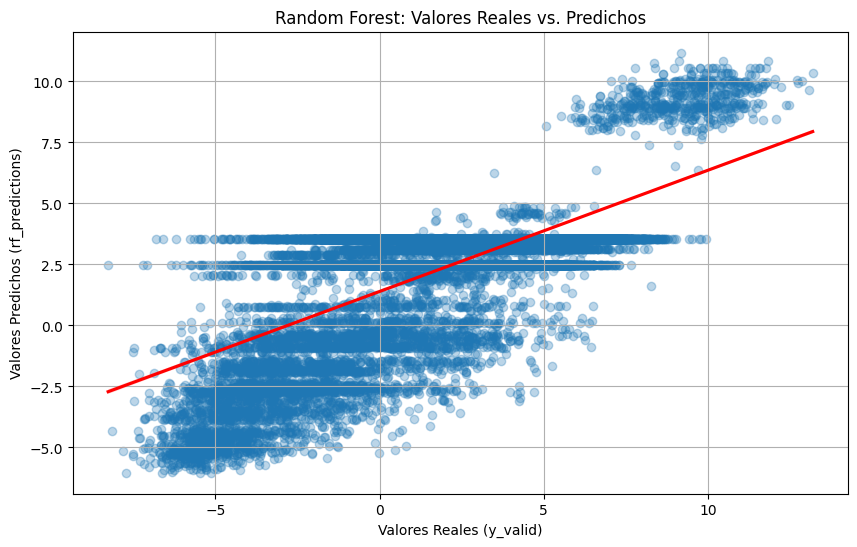

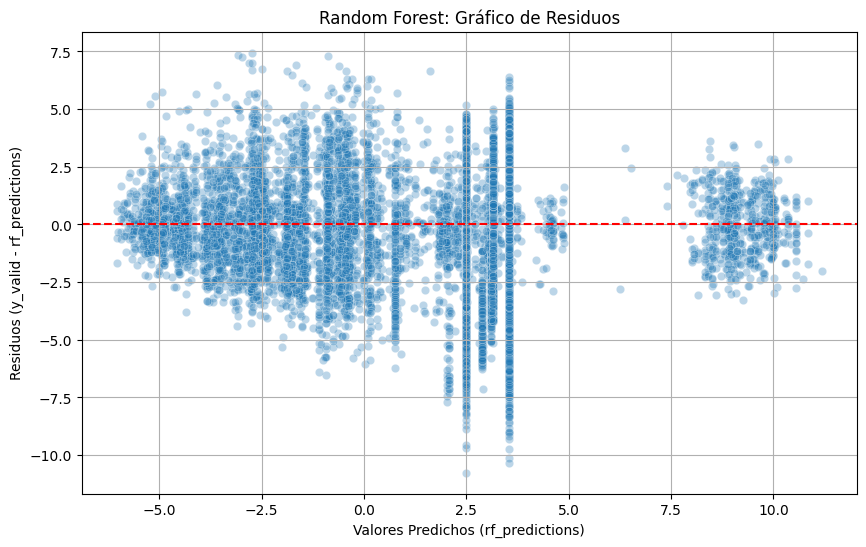

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Inicializar el modelo Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=60, max_depth=15, random_state=0, n_jobs=-1) # n_jobs=-1 para usar todos los núcleos disponibles

# Entrenar el modelo
print("Entrenando Random Forest Regressor...")
rf_model.fit(X_train_encoded, y_train)
print("Entrenamiento completado.")

# Realizar predicciones en el set de validación
rf_predictions = rf_model.predict(X_valid_encoded)

# Evaluar el rendimiento del modelo
rf_mae = mean_absolute_error(y_valid, rf_predictions)
print(f"\nError Absoluto Medio (MAE) del Random Forest: {rf_mae:.4f}")

# Calcular RMSE
rf_rmse = np.sqrt(mean_squared_error(y_valid, rf_predictions))
print(f"Root Mean Squared Error (RMSE) del Random Forest: {rf_rmse:.4f}")

# Calcular R-squared
rf_r2 = r2_score(y_valid, rf_predictions)
print(f"R-squared (R2 Score) del Random Forest: {rf_r2:.4f}")

# 1. Gráfico de dispersión de valores reales vs. predichos
plt.figure(figsize=(10, 6))
sns.regplot(x=y_valid, y=rf_predictions, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.xlabel('Valores Reales (y_valid)')
plt.ylabel('Valores Predichos (rf_predictions)')
plt.title('Random Forest: Valores Reales vs. Predichos')
plt.grid(True)
plt.show()

# 2. Gráfico de residuos
rf_residuals = y_valid - rf_predictions
plt.figure(figsize=(10, 6))
sns.scatterplot(x=rf_predictions, y=rf_residuals, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Valores Predichos (rf_predictions)')
plt.ylabel('Residuos (y_valid - rf_predictions)')
plt.title('Random Forest: Gráfico de Residuos')
plt.grid(True)
plt.show()

### Análisis de la Distribución de Datos en Variable Objetivo

Valores únicos en y_valid y sus frecuencias (top 10):
LN_IC50
4.412936    4
6.291739    3
4.570231    3
4.742380    3
5.821632    3
5.956583    3
5.951556    3
2.584915    3
5.132361    3
4.323736    3
Name: count, dtype: int64

Número total de valores únicos en y_valid: 40428


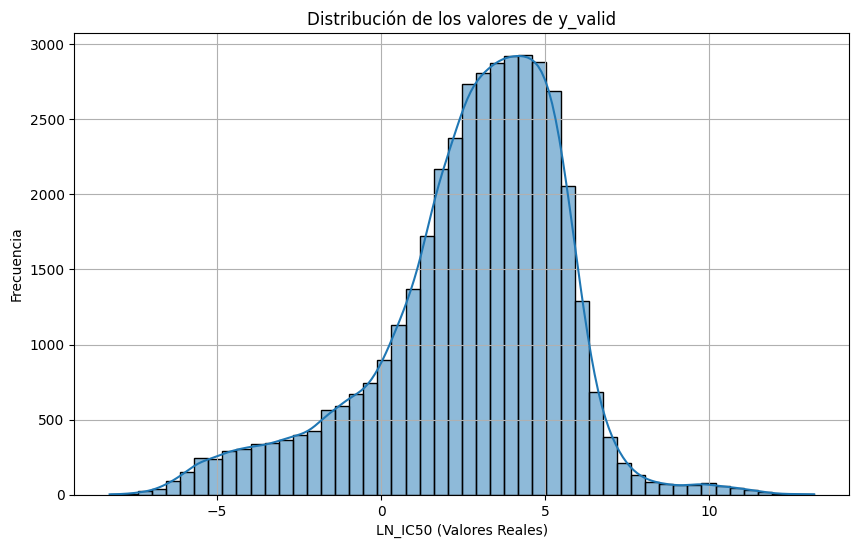

In [ ]:
# Analizar la distribución de los valores de y_valid
print("Valores únicos en y_valid y sus frecuencias (top 10):")
print(y_valid.value_counts().head(10))

print("\nNúmero total de valores únicos en y_valid:", y_valid.nunique())

# Visualizar la distribución de y_valid
plt.figure(figsize=(10, 6))
sns.histplot(y_valid, bins=50, kde=True)
plt.title('Distribución de los valores de y_valid')
plt.xlabel('LN_IC50 (Valores Reales)')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

### Recalibrado de Random Forest y Segunda Predicción

Entrenando Random Forest Regressor...
Entrenamiento completado.

Error Absoluto Medio (MAE) del Random Forest: 1.3392
Root Mean Squared Error (RMSE) del Random Forest: 1.7023
R-squared (R2 Score) del Random Forest: 0.6405


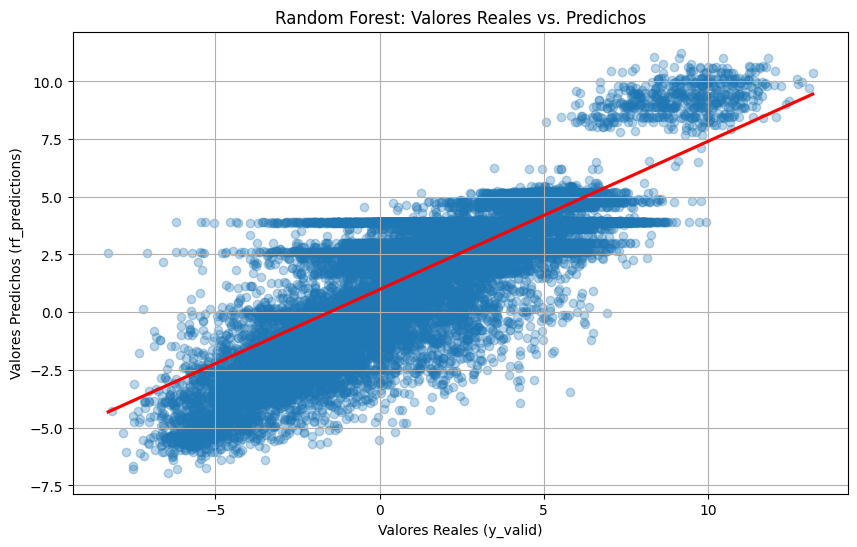

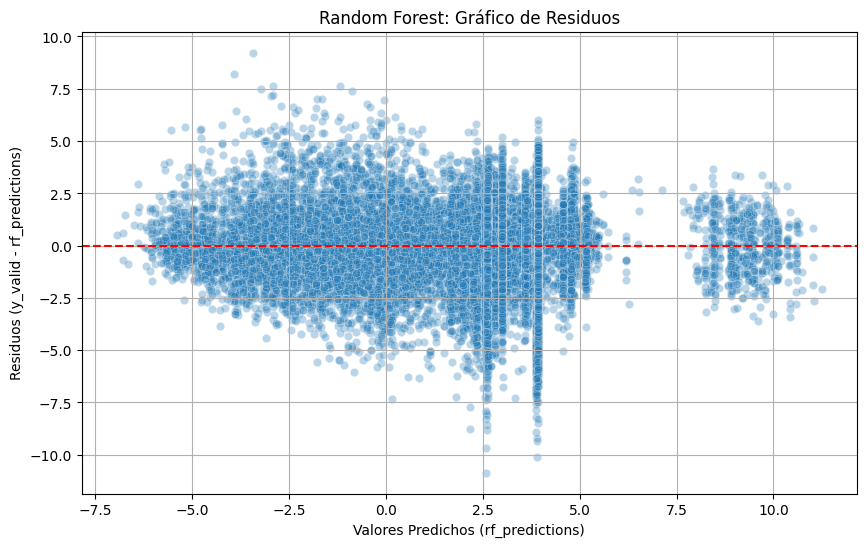

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Inicializar el modelo Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=70, max_depth=30, random_state=0, n_jobs=-1) # n_jobs=-1 para usar todos los núcleos disponibles

# Entrenar el modelo
print("Entrenando Random Forest Regressor...")
rf_model.fit(X_train_encoded, y_train)
print("Entrenamiento completado.")

# Realizar predicciones en el set de validación
rf_predictions = rf_model.predict(X_valid_encoded)

# Evaluar el rendimiento del modelo
rf_mae = mean_absolute_error(y_valid, rf_predictions)
print(f"\nError Absoluto Medio (MAE) del Random Forest: {rf_mae:.4f}")

# Calcular RMSE
rf_rmse = np.sqrt(mean_squared_error(y_valid, rf_predictions))
print(f"Root Mean Squared Error (RMSE) del Random Forest: {rf_rmse:.4f}")

# Calcular R-squared
rf_r2 = r2_score(y_valid, rf_predictions)
print(f"R-squared (R2 Score) del Random Forest: {rf_r2:.4f}")

# 1. Gráfico de dispersión de valores reales vs. predichos
plt.figure(figsize=(10, 6))
sns.regplot(x=y_valid, y=rf_predictions, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.xlabel('Valores Reales (y_valid)')
plt.ylabel('Valores Predichos (rf_predictions)')
plt.title('Random Forest: Valores Reales vs. Predichos')
plt.grid(True)
plt.show()

# 2. Gráfico de residuos
rf_residuals = y_valid - rf_predictions
plt.figure(figsize=(10, 6))
sns.scatterplot(x=rf_predictions, y=rf_residuals, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Valores Predichos (rf_predictions)')
plt.ylabel('Residuos (y_valid - rf_predictions)')
plt.title('Random Forest: Gráfico de Residuos')
plt.grid(True)
plt.show()

### Modelo de XGBoost Regressor



Entrenando XGBoost Regressor...
Entrenamiento completado.

Error Absoluto Medio (MAE) del XGBoost: 1.1010
Root Mean Squared Error (RMSE) para modelo_1 con nuevo filtro: 1.4537
R-squared (R2 Score) para modelo_1 con nuevo filtro: 0.7379


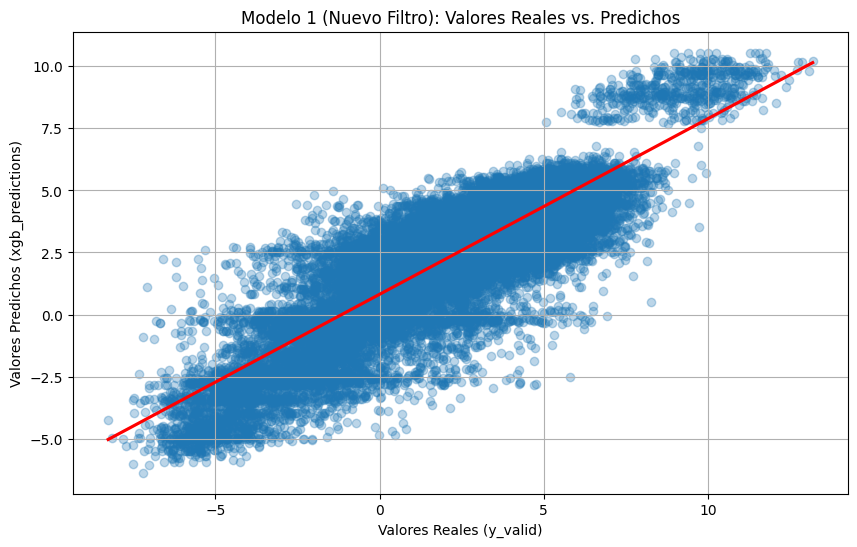

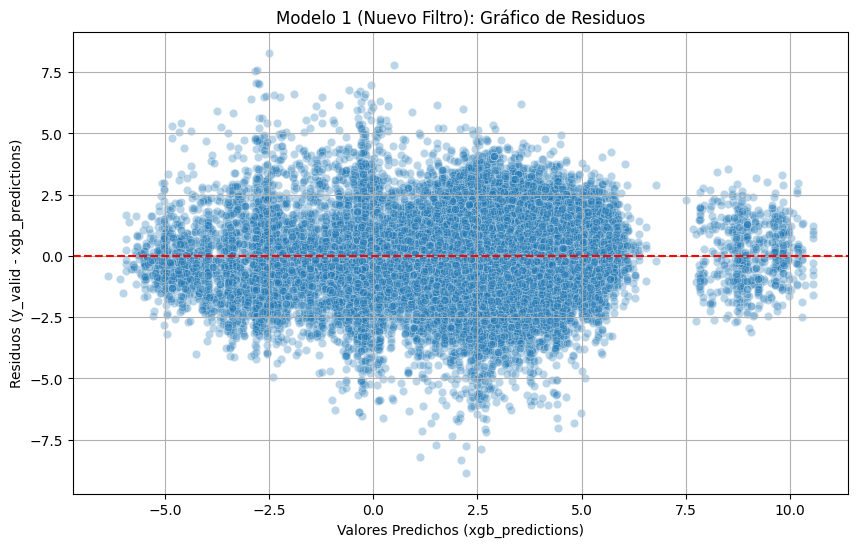

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Inicializar el modelo XGBoost Regressor
xgb_model = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, n_jobs=-1, random_state=0) # n_jobs=-1 para usar todos los núcleos disponibles

# Entrenar el modelo
print("Entrenando XGBoost Regressor...")
xgb_model.fit(X_train_encoded, y_train,
              eval_set=[(X_valid_encoded, y_valid)], verbose=False) # Evaluar en el set de validación
print("Entrenamiento completado.")

# Realizar predicciones en el set de validación
xgb_predictions = xgb_model.predict(X_valid_encoded)

# Evaluar el rendimiento del modelo
xgb_mae = mean_absolute_error(y_valid, xgb_predictions)
print(f"\nError Absoluto Medio (MAE) del XGBoost: {xgb_mae:.4f}")

# Calcular RMSE
rmse_1_new = np.sqrt(mean_squared_error(y_valid, xgb_predictions))
print(f"Root Mean Squared Error (RMSE) para modelo_1 con nuevo filtro: {rmse_1_new:.4f}")

# Calcular R-squared
r2_1_new = r2_score(y_valid, xgb_predictions)
print(f"R-squared (R2 Score) para modelo_1 con nuevo filtro: {r2_1_new:.4f}")

# 1. Gráfico de dispersión de valores reales vs. predichos
plt.figure(figsize=(10, 6))
sns.regplot(x=y_valid, y=xgb_predictions, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.xlabel('Valores Reales (y_valid)')
plt.ylabel('Valores Predichos (xgb_predictions)')
plt.title('Modelo 1 (Nuevo Filtro): Valores Reales vs. Predichos')
plt.grid(True)
plt.show()

# 2. Gráfico de residuos
residuals_1_new = y_valid - xgb_predictions
plt.figure(figsize=(10, 6))
sns.scatterplot(x=xgb_predictions, y=residuals_1_new, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Valores Predichos (xgb_predictions)')
plt.ylabel('Residuos (y_valid - xgb_predictions)')
plt.title('Modelo 1 (Nuevo Filtro): Gráfico de Residuos')
plt.grid(True)
plt.show()

### Modelo de  CatBoost Regressor

In [ ]:
import sys
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.4 MB/s eta 0:00:00


Entrenando CatBoost Regressor...
Entrenamiento completado.

Error Absoluto Medio (MAE) del CatBoost: 1.0795
Root Mean Squared Error (RMSE) del CatBoost: 1.4258
R-squared (R2 Score) del CatBoost: 0.7478


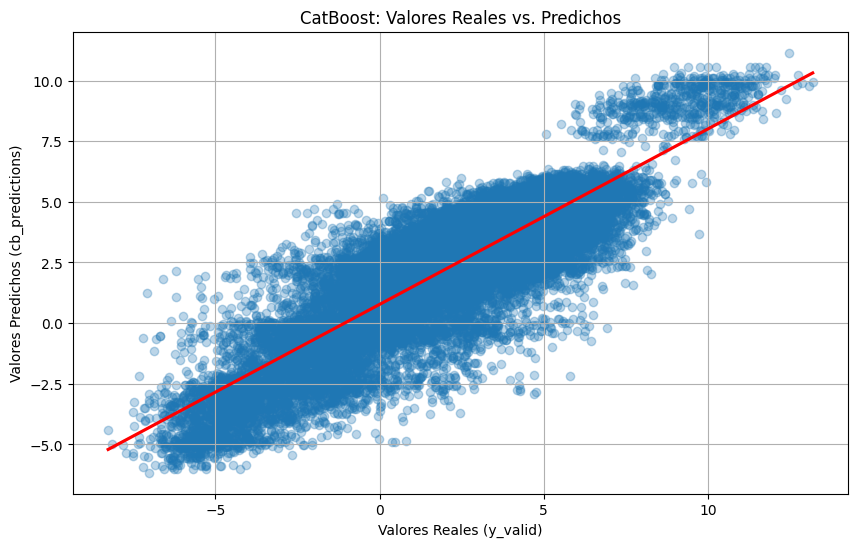

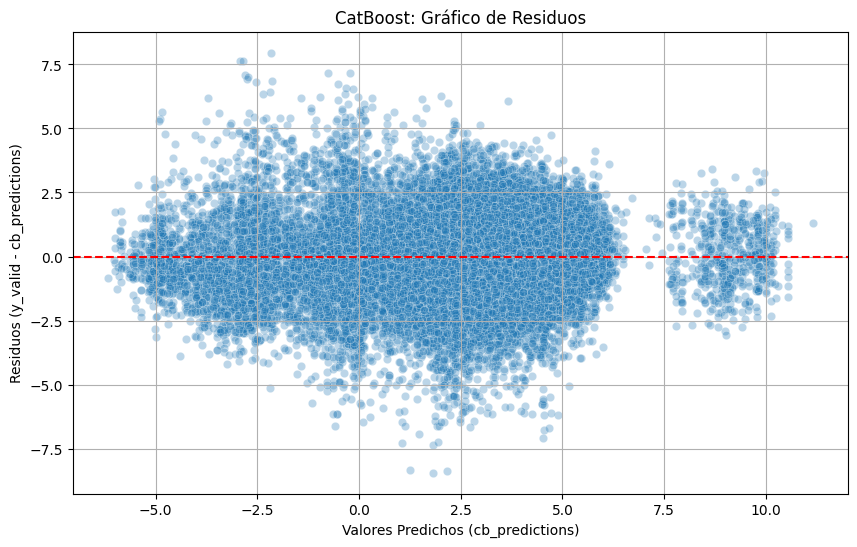

In [ ]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Inicializar el modelo CatBoost Regressor
# Para CatBoost, dado que las características ya están one-hot encoded, no necesitamos pasar cat_features.
cb_model = CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=10,
                             random_seed=0, verbose=False, # verbose=False para no imprimir el progreso
                             allow_writing_files=False) # Para evitar errores en algunos entornos

# Entrenar el modelo
print("Entrenando CatBoost Regressor...")
cb_model.fit(X_train_encoded, y_train,
              eval_set=(X_valid_encoded, y_valid),
              early_stopping_rounds=50, # Early stopping para evitar sobreajuste
              verbose=False)
print("Entrenamiento completado.")

# Realizar predicciones en el set de validación
cb_predictions = cb_model.predict(X_valid_encoded)

# Evaluar el rendimiento del modelo
cb_mae = mean_absolute_error(y_valid, cb_predictions)
print(f"\nError Absoluto Medio (MAE) del CatBoost: {cb_mae:.4f}")

# Calcular RMSE
cb_rmse = np.sqrt(mean_squared_error(y_valid, cb_predictions))
print(f"Root Mean Squared Error (RMSE) del CatBoost: {cb_rmse:.4f}")

# Calcular R-squared
cb_r2 = r2_score(y_valid, cb_predictions)
print(f"R-squared (R2 Score) del CatBoost: {cb_r2:.4f}")

# 1. Gráfico de dispersión de valores reales vs. predichos
plt.figure(figsize=(10, 6))
sns.regplot(x=y_valid, y=cb_predictions, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.xlabel('Valores Reales (y_valid)')
plt.ylabel('Valores Predichos (cb_predictions)')
plt.title('CatBoost: Valores Reales vs. Predichos')
plt.grid(True)
plt.show()

# 2. Gráfico de residuos
cb_residuals = y_valid - cb_predictions
plt.figure(figsize=(10, 6))
sns.scatterplot(x=cb_predictions, y=cb_residuals, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Valores Predichos (cb_predictions)')
plt.ylabel('Residuos (y_valid - cb_predictions)')
plt.title('CatBoost: Gráfico de Residuos')
plt.grid(True)
plt.show()

### Modelo de Linear SVR

Entrenando Linear SVR...
Entrenamiento completado.

Error Absoluto Medio (MAE) del Linear SVR: 1.1183
Root Mean Squared Error (RMSE) del Linear SVR: 1.5088
R-squared (R2 Score) del Linear SVR: 0.7176


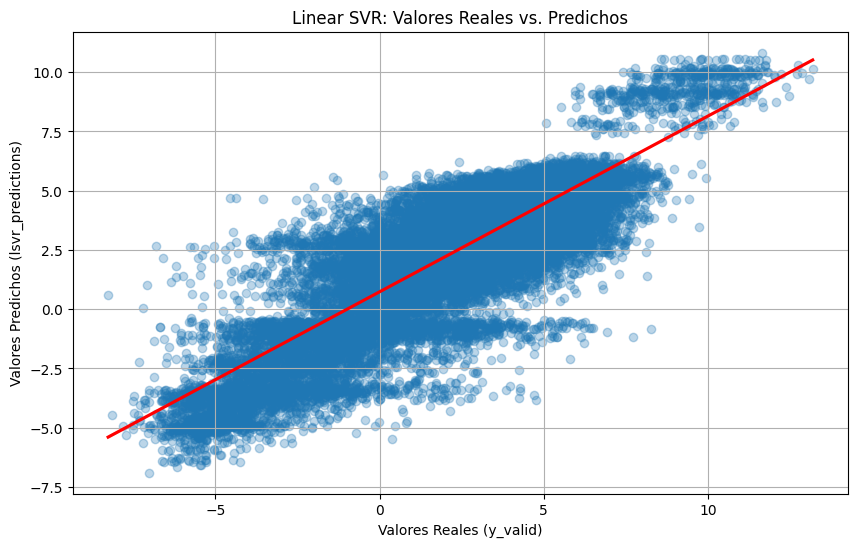

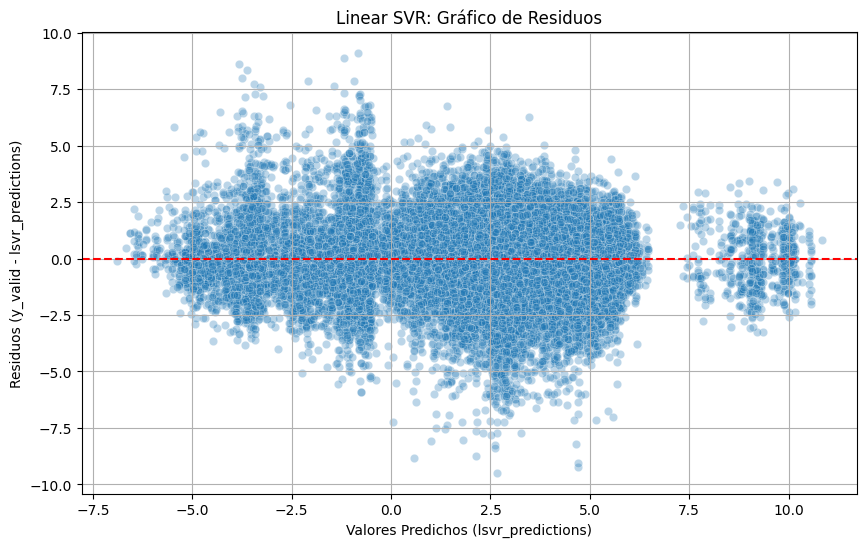

In [ ]:
from sklearn.svm import LinearSVR # Usamos LinearSVR por eficiencia en datasets grandes
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Inicializar el modelo LinearSVR
# C es el parámetro de regularización, epsilon es la tolerancia para el margen de error
lsvr_model = LinearSVR(epsilon=0.1, C=1.0, random_state=0, max_iter=5000) # Aumentar max_iter si no converge

# Entrenar el modelo
print("Entrenando Linear SVR...")
lsvr_model.fit(X_train_encoded, y_train)
print("Entrenamiento completado.")

# Realizar predicciones en el set de validación
lsvr_predictions = lsvr_model.predict(X_valid_encoded)

# Evaluar el rendimiento del modelo
lsvr_mae = mean_absolute_error(y_valid, lsvr_predictions)
print(f"\nError Absoluto Medio (MAE) del Linear SVR: {lsvr_mae:.4f}")

# Calcular RMSE
lsvr_rmse = np.sqrt(mean_squared_error(y_valid, lsvr_predictions))
print(f"Root Mean Squared Error (RMSE) del Linear SVR: {lsvr_rmse:.4f}")

# Calcular R-squared
lsvr_r2 = r2_score(y_valid, lsvr_predictions)
print(f"R-squared (R2 Score) del Linear SVR: {lsvr_r2:.4f}")

# 1. Gráfico de dispersión de valores reales vs. predichos
plt.figure(figsize=(10, 6))
sns.regplot(x=y_valid, y=lsvr_predictions, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.xlabel('Valores Reales (y_valid)')
plt.ylabel('Valores Predichos (lsvr_predictions)')
plt.title('Linear SVR: Valores Reales vs. Predichos')
plt.grid(True)
plt.show()

# 2. Gráfico de residuos
lsvr_residuals = y_valid - lsvr_predictions
plt.figure(figsize=(10, 6))
sns.scatterplot(x=lsvr_predictions, y=lsvr_residuals, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Valores Predichos (lsvr_predictions)')
plt.ylabel('Residuos (y_valid - lsvr_predictions)')
plt.title('Linear SVR: Gráfico de Residuos')
plt.grid(True)
plt.show()

Resumen comparativo de los resultados obtenidos para cada modelo en el conjunto de validación:

**Random Forest Regressor (configuración inicial):**

MAE: 1.5907
RMSE: 2.0054
R2 Score: 0.5011

**Random Forest Regressor (parámetros ajustados):**

MAE: 1.3392
RMSE: 1.7023
R2 Score: 0.6405

**XGBoost Regressor:**

MAE: 1.1010
RMSE: 1.4537
R2 Score: 0.7379

**CatBoost Regressor:**

MAE: 1.0795
RMSE: 1.4258
R2 Score: 0.7478

**Linear SVR:**

MAE: 1.1183
RMSE: 1.5088
R2 Score: 0.7176

### Comparativa visual de los cuatro resultados:

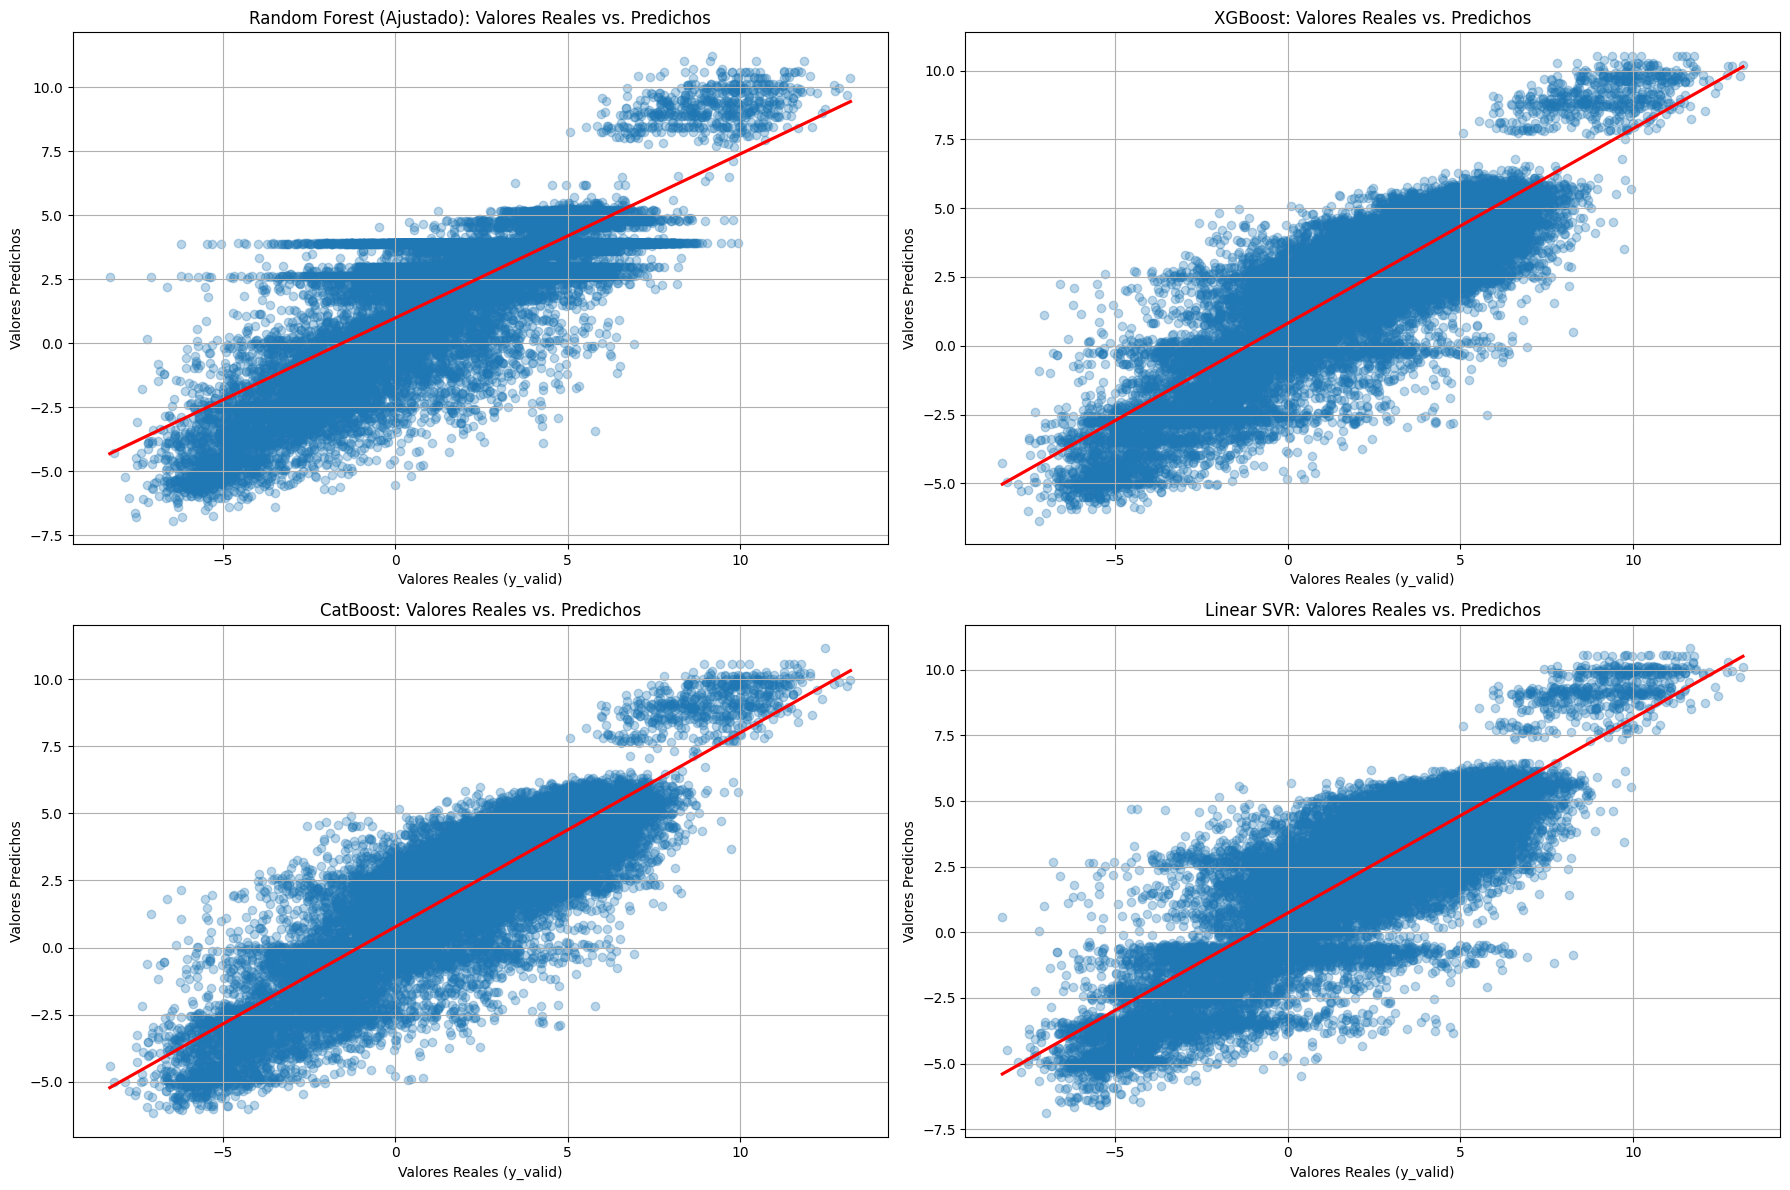

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear una figura con una red 2x2 de subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot para Random Forest Regressor (parámetros ajustados)
sns.regplot(x=y_valid, y=rf_predictions, scatter_kws={'alpha':0.3}, line_kws={'color':'red'}, ax=axes[0, 0])
axes[0, 0].set_xlabel('Valores Reales (y_valid)')
axes[0, 0].set_ylabel('Valores Predichos')
axes[0, 0].set_title('Random Forest (Ajustado): Valores Reales vs. Predichos')
axes[0, 0].grid(True)

# Plot para XGBoost Regressor
sns.regplot(x=y_valid, y=xgb_predictions, scatter_kws={'alpha':0.3}, line_kws={'color':'red'}, ax=axes[0, 1])
axes[0, 1].set_xlabel('Valores Reales (y_valid)')
axes[0, 1].set_ylabel('Valores Predichos')
axes[0, 1].set_title('XGBoost: Valores Reales vs. Predichos')
axes[0, 1].grid(True)

# Plot para CatBoost Regressor
sns.regplot(x=y_valid, y=cb_predictions, scatter_kws={'alpha':0.3}, line_kws={'color':'red'}, ax=axes[1, 0])
axes[1, 0].set_xlabel('Valores Reales (y_valid)')
axes[1, 0].set_ylabel('Valores Predichos')
axes[1, 0].set_title('CatBoost: Valores Reales vs. Predichos')
axes[1, 0].grid(True)

# Plot para Linear SVR
sns.regplot(x=y_valid, y=lsvr_predictions, scatter_kws={'alpha':0.3}, line_kws={'color':'red'}, ax=axes[1, 1])
axes[1, 1].set_xlabel('Valores Reales (y_valid)')
axes[1, 1].set_ylabel('Valores Predichos')
axes[1, 1].set_title('Linear SVR: Valores Reales vs. Predichos')
axes[1, 1].grid(True)

# Ajustar el diseño para evitar la superposición de títulos/etiquetas
plt.tight_layout()
plt.show()

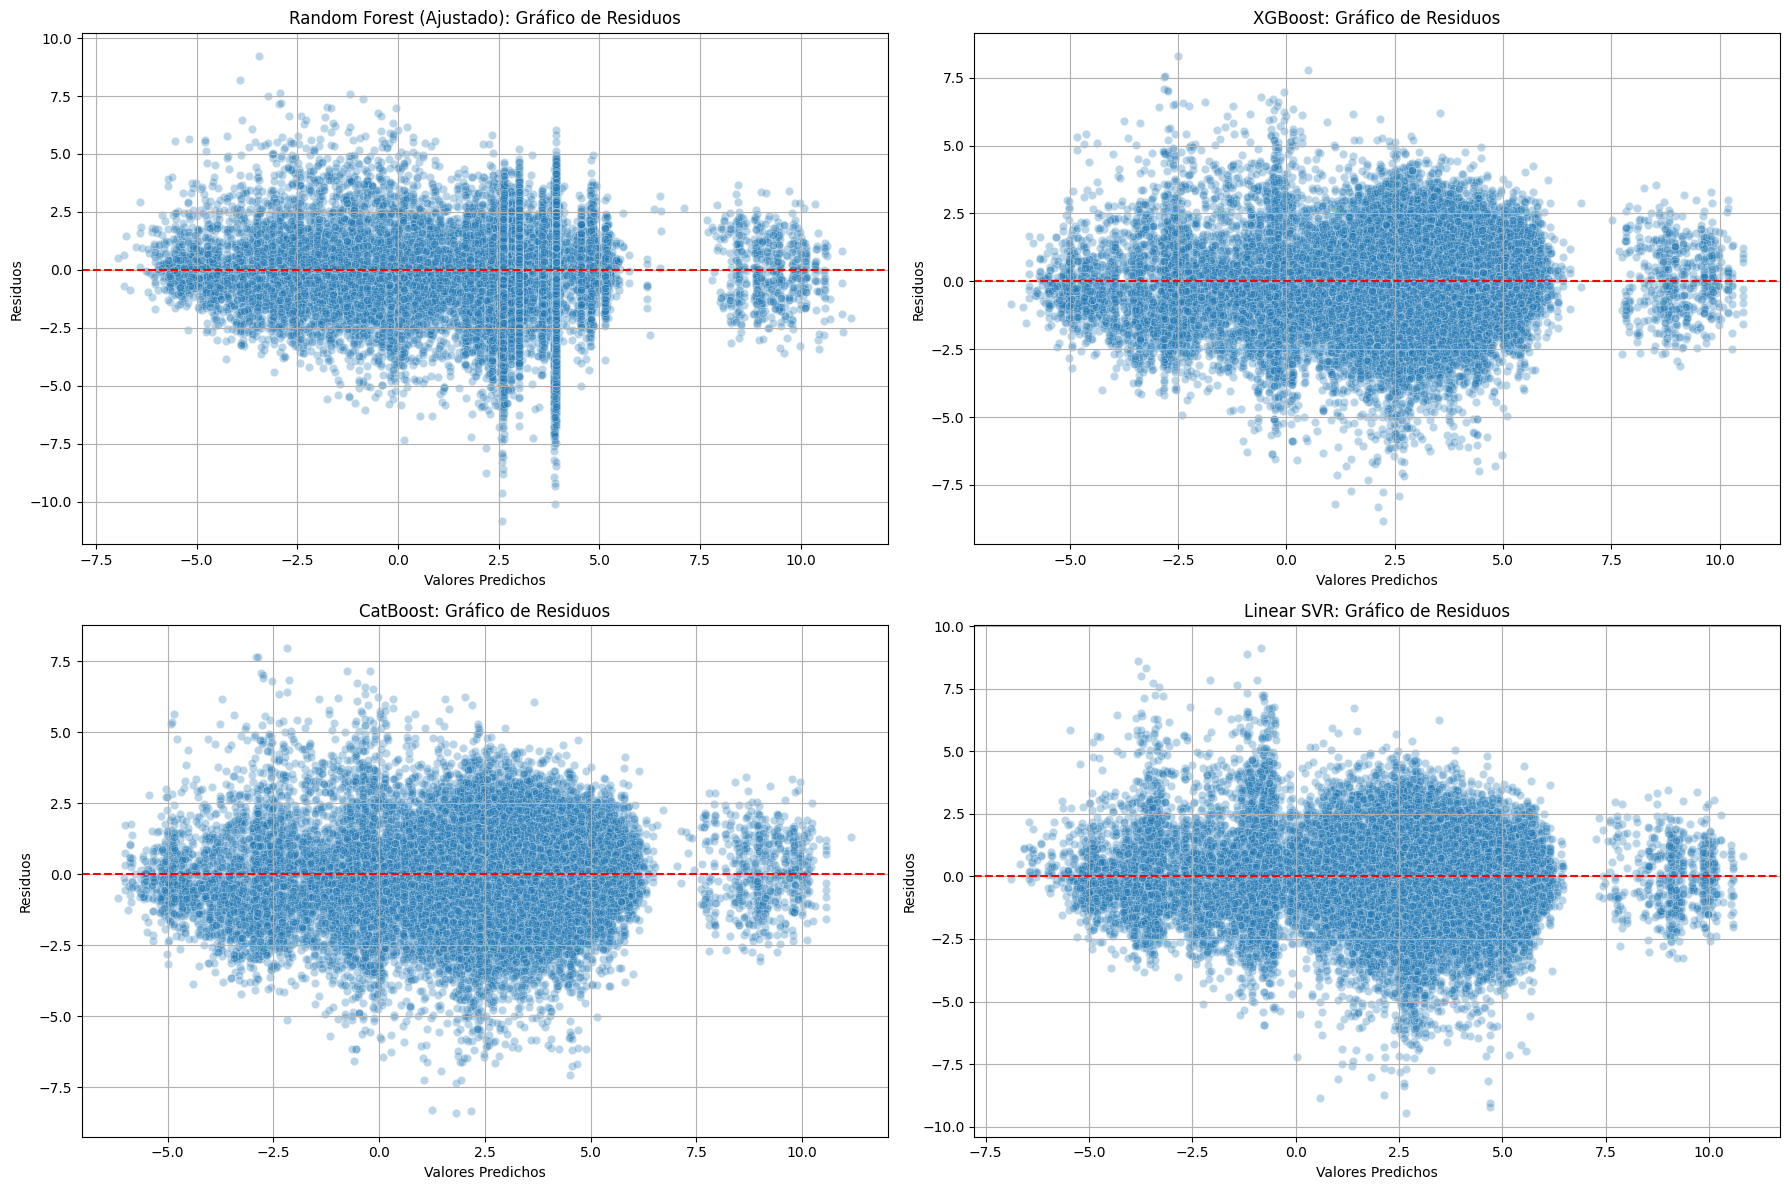

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear una figura con una red 2x2 de subplots para gráficas de residuos
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot para Random Forest Regressor
sns.scatterplot(x=rf_predictions, y=rf_residuals, alpha=0.3, ax=axes[0, 0])
axes[0, 0].axhline(y=0, color='red', linestyle='--')
axes[0, 0].set_xlabel('Valores Predichos')
axes[0, 0].set_ylabel('Residuos')
axes[0, 0].set_title('Random Forest (Ajustado): Gráfico de Residuos')
axes[0, 0].grid(True)

# Plot para XGBoost Regressor
sns.scatterplot(x=xgb_predictions, y=residuals_1_new, alpha=0.3, ax=axes[0, 1])
axes[0, 1].axhline(y=0, color='red', linestyle='--')
axes[0, 1].set_xlabel('Valores Predichos')
axes[0, 1].set_ylabel('Residuos')
axes[0, 1].set_title('XGBoost: Gráfico de Residuos')
axes[0, 1].grid(True)

# Plot para CatBoost Regressor
sns.scatterplot(x=cb_predictions, y=cb_residuals, alpha=0.3, ax=axes[1, 0])
axes[1, 0].axhline(y=0, color='red', linestyle='--')
axes[1, 0].set_xlabel('Valores Predichos')
axes[1, 0].set_ylabel('Residuos')
axes[1, 0].set_title('CatBoost: Gráfico de Residuos')
axes[1, 0].grid(True)

# Plot para Linear SVR
sns.scatterplot(x=lsvr_predictions, y=lsvr_residuals, alpha=0.3, ax=axes[1, 1])
axes[1, 1].axhline(y=0, color='red', linestyle='--')
axes[1, 1].set_xlabel('Valores Predichos')
axes[1, 1].set_ylabel('Residuos')
axes[1, 1].set_title('Linear SVR: Gráfico de Residuos')
axes[1, 1].grid(True)

# Ajustar el diseño para evitar la superposición de títulos/etiquetas
plt.tight_layout()
plt.show()

## Preparar Datos para Validación Cruzada



In [ ]:
import pandas as pd

# 1. Concatenar X_train_encoded y X_valid_encoded
X_combined = pd.concat([X_train_encoded, X_valid_encoded], axis=0)

# 2. Concatenar y_train e y_valid
y_combined = pd.concat([y_train, y_valid], axis=0)

print("Dimensiones de X_combined:")
print(X_combined.shape)
print("Primeras 5 filas de X_combined:")
display(X_combined.head())

print("\nDimensiones de y_combined:")
print(y_combined.shape)
print("Primeras 5 filas de y_combined:")
display(y_combined.head())

Dimensiones de X_combined:
(202978, 293)
Primeras 5 filas de X_combined:


,GDSC Tissue descriptor 1_aero_dig_tract,GDSC Tissue descriptor 1_bone,GDSC Tissue descriptor 1_breast,GDSC Tissue descriptor 1_digestive_system,GDSC Tissue descriptor 1_kidney,GDSC Tissue descriptor 1_large_intestine,GDSC Tissue descriptor 1_leukemia,GDSC Tissue descriptor 1_lung,GDSC Tissue descriptor 1_lung_NSCLC,GDSC Tissue descriptor 1_lung_SCLC,...,TARGET_PATHWAY_JNK and p38 signaling,TARGET_PATHWAY_Metabolism,TARGET_PATHWAY_Mitosis,TARGET_PATHWAY_Other,"TARGET_PATHWAY_Other, kinases",TARGET_PATHWAY_PI3K/MTOR signaling,TARGET_PATHWAY_Protein stability and degradation,TARGET_PATHWAY_RTK signaling,TARGET_PATHWAY_WNT signaling,TARGET_PATHWAY_p53 pathway
138742,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
95962,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,True,False,False,False,False
81444,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
3438,False,False,False,True,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
15427,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False



Dimensiones de y_combined:
(202978,)
Primeras 5 filas de y_combined:


,LN_IC50
138742,6.397973
95962,3.381623
81444,4.725134
3438,-4.576098
15427,2.388213


In [ ]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import LinearSVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
from catboost import CatBoostRegressor
import numpy as np

print("Librerías y modelos necesarios para la validación cruzada K-Fold importados exitosamente.")

Necessary libraries and models for K-Fold Cross-Validation imported successfully.


In [ ]:
models = {
    'RandomForestRegressor': RandomForestRegressor(n_estimators=70, max_depth=30, random_state=0, n_jobs=-1),
    'XGBoostRegressor': xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, n_jobs=-1, random_state=0, verbosity=0), # verbosity=0 para suprimir la salida
    'CatBoostRegressor': CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=10, random_seed=0, verbose=0, allow_writing_files=False), # verbose=0 para suprimir la salida
    'LinearSVR': LinearSVR(epsilon=0.1, C=1.0, random_state=0, max_iter=5000)
}

print("Modelos inicializados exitosamente.")

Models initialized successfully.


In [ ]:
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=0)

# Diccionarios para almacenar los resultados
results = {
    'RandomForestRegressor': {'MAE': [], 'RMSE': [], 'R2': []},
    'XGBoostRegressor': {'MAE': [], 'RMSE': [], 'R2': []},
    'CatBoostRegressor': {'MAE': [], 'RMSE': [], 'R2': []},
    'LinearSVR': {'MAE': [], 'RMSE': [], 'R2': []}
}

print(f"Divisor K-Fold inicializado con {n_splits} divisiones.")
print("Diccionarios de resultados inicializados.")

K-Fold splitter initialized with 5 splits.
Results dictionaries initialized.


In [ ]:
for model_name, model in models.items():
    print(f"\nRealizando validación cruzada para: {model_name}")
    fold_count = 1
    for train_index, test_index in kf.split(X_combined, y_combined):
        X_train_fold, X_test_fold = X_combined.iloc[train_index], X_combined.iloc[test_index]
        y_train_fold, y_test_fold = y_combined.iloc[train_index], y_combined.iloc[test_index]

        # Entrenar el modelo
        print(f"  Fold {fold_count}/{n_splits} - Entrenando {model_name}...")
        if model_name == 'XGBoostRegressor':
            model.fit(X_train_fold, y_train_fold, eval_set=[(X_test_fold, y_test_fold)], verbose=False)
        elif model_name == 'CatBoostRegressor':
            model.fit(X_train_fold, y_train_fold, eval_set=(X_test_fold, y_test_fold), early_stopping_rounds=50, verbose=False)
        else:
            model.fit(X_train_fold, y_train_fold)
        print(f"  Fold {fold_count}/{n_splits} - Entrenamiento completado.")

        # Realizar predicciones
        predictions = model.predict(X_test_fold)

        # Calcular métricas
        mae = mean_absolute_error(y_test_fold, predictions)
        rmse = np.sqrt(mean_squared_error(y_test_fold, predictions))
        r2 = r2_score(y_test_fold, predictions)

        # Almacenar resultados
        results[model_name]['MAE'].append(mae)
        results[model_name]['RMSE'].append(rmse)
        results[model_name]['R2'].append(r2)

        print(f"  Fold {fold_count}/{n_splits} - MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")
        fold_count += 1

print("\nK-Fold Cross-Validation completada para todos los modelos.")


Realizando validación cruzada para: RandomForestRegressor
  Fold 1/5 - Entrenando RandomForestRegressor...
  Fold 1/5 - Entrenamiento completado.
  Fold 1/5 - MAE: 1.3431, RMSE: 1.7080, R2: 0.6372
  Fold 2/5 - Entrenando RandomForestRegressor...
  Fold 2/5 - Entrenamiento completado.
  Fold 2/5 - MAE: 1.3675, RMSE: 1.7293, R2: 0.6285
  Fold 3/5 - Entrenando RandomForestRegressor...
  Fold 3/5 - Entrenamiento completado.
  Fold 3/5 - MAE: 1.3450, RMSE: 1.7087, R2: 0.6358
  Fold 4/5 - Entrenando RandomForestRegressor...
  Fold 4/5 - Entrenamiento completado.
  Fold 4/5 - MAE: 1.3442, RMSE: 1.7064, R2: 0.6369
  Fold 5/5 - Entrenando RandomForestRegressor...
  Fold 5/5 - Entrenamiento completado.
  Fold 5/5 - MAE: 1.3431, RMSE: 1.7061, R2: 0.6388

Realizando validación cruzada para: XGBoostRegressor
  Fold 1/5 - Entrenando XGBoostRegressor...
  Fold 1/5 - Entrenamiento completado.
  Fold 1/5 - MAE: 1.0993, RMSE: 1.4556, R2: 0.7365
  Fold 2/5 - Entrenando XGBoostRegressor...
  Fold 2/5 - E

In [ ]:
print("\n--- Resumen de la Validación Cruzada (Métricas Promedio) ---")
print("\nModelo                      | MAE Promedio | RMSE Promedio | R2 Promedio")
print("----------------------------|--------------|---------------|-------------")

for model_name, metrics in results.items():
    avg_mae = np.mean(metrics['MAE'])
    avg_rmse = np.mean(metrics['RMSE'])
    avg_r2 = np.mean(metrics['R2'])
    print(f"{model_name:<27} | {avg_mae:<12.4f} | {avg_rmse:<13.4f} | {avg_r2:<11.4f}")

print("----------------------------|--------------|---------------|-------------")


--- Resumen de la Validación Cruzada (Métricas Promedio) ---

Modelo                      | MAE Promedio | RMSE Promedio | R2 Promedio
----------------------------|--------------|---------------|-------------
RandomForestRegressor       | 1.3486       | 1.7117        | 0.6355     
XGBoostRegressor            | 1.1052       | 1.4599        | 0.7348     
CatBoostRegressor           | 1.0820       | 1.4295        | 0.7457     
LinearSVR                   | 1.1231       | 1.5166        | 0.7138     
----------------------------|--------------|---------------|-------------


### Resumen Comparativo del Rendimiento de los Modelos


*   **CatBoost Regressor:**
    *   MAE Promedio: 1.0820
    *   RMSE Promedio: 1.4295
    *   R2 Promedio: 0.7457

*   **XGBoost Regressor:**
    *   MAE Promedio: 1.1052
    *   RMSE Promedio: 1.4599
    *   R2 Promedio: 0.7348

*   **Linear SVR:**
    *   MAE Promedio: 1.1231
    *   RMSE Promedio: 1.5166
    *   R2 Promedio: 0.7138

*   **Random Forest Regressor:**
    *   MAE Promedio: 1.3486
    *   RMSE Promedio: 1.7117
    *   R2 Promedio: 0.6355


